In [1]:
!pip install "numpy<2,>=1.13" "pandas~=1.1" "matplotlib<4,>=2.1" "scipy<2,>=0.18" "scikit-learn>=0.19" "mpl-axes-aligner<2,>=1.1"

  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [20 lines of output]
  Traceback (most recent call last):
    File "C:\Users\Nienke\anaconda\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\Nienke\anaconda\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Nienke\anaconda\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
      return hook(config_settings)
             ^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Nienke\AppData\Local\Temp\pip-build-env-in9j2t53\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_wheel
      return self._get_build_requires(c

In [2]:
!git clone https://github.com/CANAL-amsterdam/Foundations-of-Cultural-and-Social-Data-Analysis
%cd Foundations-of-Cultural-and-Social-Data-Analysis/03-vector-space-model
!ls

'git' is not recognized as an internal or external command,

[WinError 3] Het systeem kan het opgegeven pad niet vinden: 'Foundations-of-Cultural-and-Social-Data-Analysis/03-vector-space-model'
C:\Users\Nienke



operable program or batch file.
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
pip install --user -U nltk


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 1.5 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.6 MB 1.6 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 1.3 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.4 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import nltk

In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nienke\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## Exercises

In this chapter's exercises, we will employ the vector space model to explore a rich and
unique collection of '<span class="index">chain letters</span>', which were collected,
transcribed, and digitised by {cite:t}`vanarsdale:2019`. Here, we focus on one of the
largest chain letter categories: "luck chain letters". The recipients of these letters are
warned against sin, and the letters often contain prayers and emphasize good behavior according to Christian beliefs. The most characteristic and equally intriguing aspect of these chain letters is their explicit demand to be copied and redistributed to a number of successive recipients. If the recipient does not obey the letter's demands, and thus breaks the chain, he or she will be punished and bad fortune will be inevitable.

The following code block loads the corpus into memory. Two lists are created, one for the contents of the letters and one for their dating. The letters are loaded in chronological order.

In [47]:
import csv

letters, years = [], []
with open(r"C:\Users\Nienke\Python tutorial\3560761\data\03-vector-space-model\data\chain-letters.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        letters.append(row["letter"])
        years.append(int(row["year"]))

In [48]:
letters[0]

'Endless Prayer Chain\n\n Oh, Lord Jesus we implore, oh Eternal God, to have mercy on all sin by thy \nprecious blood and take us to be with thee eternally. \nÂ\xa0Amen.  This prayer was sent by Bishop Lawrence recommending it\nto be rewritten and sent to nine other persons. He who will not send it will \nbe effected by some misfortune. One person who paid no attention met with \na terrible accident. He who rewrites this prayer for nine days and sends it\nto nine others commencing on the day it was received will on the ninth day\nexperience some great joy. It is said at Jerusalem at the Holy Feast that\nhe who writes this prayer will be delivered from every calamity.\n Please do not break the chain.'

In [49]:
tokens = set()

for row in letters:
    tokensrow = row.split()
    for token in tokensrow:
        tokens.add(token)  #append
        #doe set op het eind, eerst lijst


alltokens = list(tokens)

print(len(alltokens))


8473


In [50]:
import nltk
import nltk.tokenize

#download the most recent punkt package
nltk.download('punkt', quiet=True)

tokens = nltk.tokenize.word_tokenize(letters[0], language= 'english')
print(tokens)
print(len(tokens))
#Er zijn 140 unieke tokens

['Endless', 'Prayer', 'Chain', 'Oh', ',', 'Lord', 'Jesus', 'we', 'implore', ',', 'oh', 'Eternal', 'God', ',', 'to', 'have', 'mercy', 'on', 'all', 'sin', 'by', 'thy', 'precious', 'blood', 'and', 'take', 'us', 'to', 'be', 'with', 'thee', 'eternally', '.', 'Â', 'Amen', '.', 'This', 'prayer', 'was', 'sent', 'by', 'Bishop', 'Lawrence', 'recommending', 'it', 'to', 'be', 'rewritten', 'and', 'sent', 'to', 'nine', 'other', 'persons', '.', 'He', 'who', 'will', 'not', 'send', 'it', 'will', 'be', 'effected', 'by', 'some', 'misfortune', '.', 'One', 'person', 'who', 'paid', 'no', 'attention', 'met', 'with', 'a', 'terrible', 'accident', '.', 'He', 'who', 'rewrites', 'this', 'prayer', 'for', 'nine', 'days', 'and', 'sends', 'it', 'to', 'nine', 'others', 'commencing', 'on', 'the', 'day', 'it', 'was', 'received', 'will', 'on', 'the', 'ninth', 'day', 'experience', 'some', 'great', 'joy', '.', 'It', 'is', 'said', 'at', 'Jerusalem', 'at', 'the', 'Holy', 'Feast', 'that', 'he', 'who', 'writes', 'this', 'praye

In [51]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nienke\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
import re


PUNCT_RE = re.compile(r'[^\w\s]+$')


def is_punct(string):
    """Check if STRING is a punctuation marker or a sequence of
       punctuation markers.

    Arguments:
        string (str): a string to check for punctuation markers.

    Returns:
        bool: True is string is a (sequence of) punctuation marker(s),
            False otherwise.

    Examples:
        >>> is_punct("!")
        True
        >>> is_punct("Bonjour!")
        False
        >>> is_punct("¿Te gusta el verano?")
        False
        >>> is_punct("...")
        True
        >>> is_punct("«»...")
        True

    """
    return PUNCT_RE.match(string) is not None

In [53]:
def preprocess_text(text, language, lowercase=True):
    """Preprocess a text.

    Perform a text preprocessing procedure, which transforms a string
    object into a list of word tokens without punctuation markers.

    Arguments:
        text (str): a string representing a text.
        language (str): a string specifying the language of text.
        lowercase (bool, optional): Set to True to lowercase all
            word tokens. Defaults to True.

    Returns:
        list: a list of word tokens extracted from text, excluding
            punctuation.

    Examples:
        >>> preprocess_text("Ah! Monsieur, c'est donc vous?", 'french')
        ["ah", "monsieur", "c'est", "donc", "vous"]

    """
    if lowercase:
        text = text.lower()
    tokens = nltk.tokenize.word_tokenize(text, language=language)
    tokens = [token for token in tokens if not is_punct(token)]
    return tokens

In [54]:
import collections
import csv

vocabulary = collections.Counter()

with open(r"C:\Users\Nienke\Python tutorial\3560761\data\03-vector-space-model\data\chain-letters.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        vocabulary.update(preprocess_text(row['letter'], 'english'))
    #for document in f:
        #vocabulary.update(preprocess_text(document, 'french'))

In [55]:
print(f)

<_io.TextIOWrapper name='C:\\Users\\Nienke\\Python tutorial\\3560761\\data\\03-vector-space-model\\data\\chain-letters.csv' mode='r' encoding='cp1252'>


In [56]:
print(vocabulary.most_common(n=5))

[('â', 24898), ('the', 5365), ('to', 3544), ('and', 3372), ('it', 3124)]


In [57]:
print('Original vocabulary size:', len(vocabulary))
pruned_vocabulary = {token for token, count in vocabulary.items() if count > 1}
#print(pruned_vocabulary)
print('Pruned vocabulary size:', len(pruned_vocabulary))

Original vocabulary size: 5725
Pruned vocabulary size: 2532


In [58]:
n = 5
print('Original vocabulary size:', len(vocabulary))
pruned_vocabulary = {token for token, _ in vocabulary.most_common()[n:]}
print('Pruned vocabulary size:', len(pruned_vocabulary))

Original vocabulary size: 5725
Pruned vocabulary size: 5720


In [59]:
def extract_vocabulary(tokenized_corpus, min_count=1, max_count=float('inf')):
    """Extract a vocabulary from a tokenized corpus.

    Arguments:
        tokenized_corpus (list): a tokenized corpus represented, list
            of lists of strings.
        min_count (int, optional): the minimum occurrence count of a
            vocabulary item in the corpus.
        max_count (int, optional): the maximum occurrence count of a
            vocabulary item in the corpus. Defaults to inf.

    Returns:
        list: An alphabetically ordered list of unique words in the
            corpus, of which the frequencies adhere to the specified
            minimum and maximum count.

    Examples:
        >>> corpus = [['the', 'man', 'love', 'man', 'the'],
                      ['the', 'love', 'book', 'wise', 'drama'],
                      ['a', 'story', 'book', 'drama']]
        >>> extract_vocabulary(corpus, min_count=2)
        ['book', 'drama', 'love', 'man', 'the']

    """
    vocabulary = collections.Counter()
    for document in tokenized_corpus:
        vocabulary.update(document)
    vocabulary = {word for word, count in vocabulary.items()
                  if count >= min_count and count <= max_count}
    return sorted(vocabulary)

In [60]:
letters_tok = [preprocess_text(letter, 'english') for letter in letters]
vocabulary = extract_vocabulary(letters_tok, min_count=1)

In [61]:
def extract_vocabulary(tokenized_corpus, min_count=1, max_count=float('inf')):
    """Extract a vocabulary from a tokenized corpus.

    Arguments:
        tokenized_corpus (list): a tokenized corpus represented, list
            of lists of strings.
        min_count (int, optional): the minimum occurrence count of a
            vocabulary item in the corpus.
        max_count (int, optional): the maximum occurrence count of a
            vocabulary item in the corpus. Defaults to inf.

    Returns:
        list: An alphabetically ordered list of unique words in the
            corpus, of which the frequencies adhere to the specified
            minimum and maximum count.

    Examples:
        >>> corpus = [['the', 'man', 'love', 'man', 'the'],
                      ['the', 'love', 'book', 'wise', 'drama'],
                      ['a', 'story', 'book', 'drama']]
        >>> extract_vocabulary(corpus, min_count=2)
        ['book', 'drama', 'love', 'man', 'the']

    """
    vocabulary = collections.Counter()
    for document in tokenized_corpus:
        vocabulary.update(document)
    vocabulary = {word for word, count in vocabulary.items()
                  if count >= min_count and count <= max_count}
    return sorted(vocabulary)

In [63]:
tokenized_corpus = [preprocess_text(letter, 'english') for letter in letters]
vocabulary = extract_vocabulary(tokenized_corpus)

In [64]:
bags_of_words = []
for document in tokenized_corpus:
    tokens = [word for word in document if word in vocabulary]
    bags_of_words.append(collections.Counter(tokens))

print(bags_of_words[2])

Counter({'to': 4, 'i': 2, 'be': 2, 'prayer': 2, 'have': 2, 'from': 2, 'o': 2, 'thee': 2, 'us': 2, 'want': 1, 'you': 1, 'a': 1, 'link': 1, 'in': 1, 'an': 1, 'endless': 1, 'chain': 1, 'which': 1, 'received': 1, 'some': 1, 'sister': 1, 'it': 1, 'explains': 1, 'itself': 1, 'the': 1, 'is': 1, 'as': 1, 'follows': 1, 'lord': 1, 'jesus': 1, 'christ': 1, 'we': 1, 'implore': 1, 'eternal': 1, 'god': 1, 'mercy': 1, 'on': 1, 'all': 1, 'mankind': 1, 'keep': 1, 'sin': 1, 'by': 1, 'thy': 1, 'precious': 1, 'blood': 1, 'and': 1, 'take': 1, 'with': 1, 'eternally': 1, 'â': 1, 'amen': 1})


In [65]:
def corpus2dtm(tokenized_corpus, vocabulary):
    """Transform a tokenized corpus into a document-term matrix.

    Arguments:
        tokenized_corpus (list): a tokenized corpus as a list of
        lists of strings. vocabulary (list): A list of unique words.

    Returns:
        list: A list of lists representing the frequency of each term
              in `vocabulary` for each document in the corpus.

    Examples:
        >>> tokenized_corpus = [['the', 'man', 'man', 'smart'],
                                ['a', 'the', 'man' 'love'],
                                ['love', 'book', 'journey']]
        >>> vocab = ['book', 'journey', 'man', 'love']
        >>> corpus2dtm(tokenized_corpus, vocabulary)
        [[0, 0, 2, 0], [0, 0, 1, 1], [1, 1, 0, 1]]

    """
    document_term_matrix = []
    for document in tokenized_corpus:
        document_counts = collections.Counter(document)
        row = [document_counts[word] for word in vocabulary]
        document_term_matrix.append(row)
    return document_term_matrix


document_term_matrix = corpus2dtm(tokenized_corpus, vocabulary)

In [67]:
import numpy as np

document_term_matrix = np.array(document_term_matrix)
print(document_term_matrix.shape)

(554, 5725)


In [68]:
letters_tok = [preprocess_text(letter, 'english') for letter in letters]
vocabulary = extract_vocabulary(letters_tok, min_count=1)
document_term_matrix = np.array(corpus2dtm(letters_tok, vocabulary))
print(f"document-term matrix with "
      f"|D| = {document_term_matrix.shape[0]} documents and "
      f"|V| = {document_term_matrix.shape[1]} words.")

document-term matrix with |D| = 554 documents and |V| = 5725 words.


In [69]:
import pandas as pd

pd.DataFrame(document_term_matrix, columns=vocabulary)

,'74,'ancient,'buddie,'cancel,'chain,'d,'god,'he,'in,'is,...,â£,"â£10,000.00","â£2,000,000","â£32,000","â£40,000","â£68,000","â£7,773,000","â£70,000","â£775,000",â½
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
550,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
551,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
552,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [70]:
import numpy as np

document_term_matrix = np.array(document_term_matrix)
print(document_term_matrix.shape)

(554, 5725)


In [72]:

print(document_term_matrix.sum())
#Er zijn 142562 word tokens

142562


In [73]:
# Excercise 3
words_per_letter = document_term_matrix.sum(axis=1)
print(words_per_letter.mean())

257.3321299638989


In [74]:
#Excercise 4
years = np.array(years)

In [75]:
words_per_letter = document_term_matrix.sum(axis=1)

In [79]:
before_1950 = words_per_letter[years < 1950].mean()
after_1950 = words_per_letter[years >= 1950].mean()

print(before_1950)
print(after_1950)

137.45644599303137
386.187265917603


In [80]:
import matplotlib.pyplot as plt

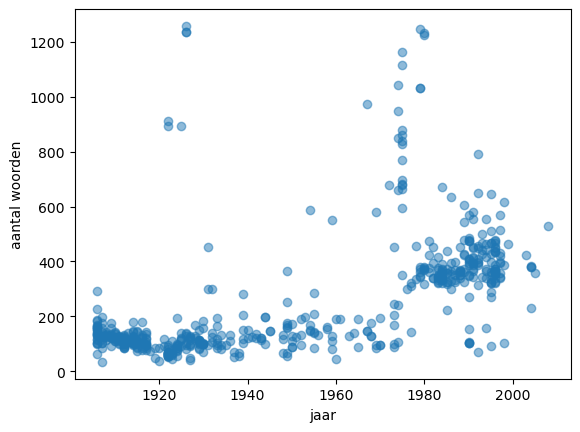

In [82]:
fig, ax = plt.subplots()
ax.scatter(years, words_per_letter, alpha=0.5)
ax.set(xlabel='jaar', ylabel='aantal woorden')
plt.show()
#Rond 1980 worden de brieven plotseling veel langer

### Easy
1. Use the preprocessing functions from section **Text Preprocessing** to create (i) a tokenized version of the
   corpus, and (ii) a list representing the vocabulary of the corpus. How many unique
   words (i.e., word types) are there?
2. Transform the tokenized letters into a document-term matrix, and convert the matrix
   into a two-dimensional NumPy array. How many word tokens are there in the corpus?
3. What is the average number of words per letter? (Hint: use NumPy's `sum()` and `mean()` to
   help you with the necessary arithmetic.)

### Moderate
1. The length of the chain letters has changed considerably over the years. Compute the
   average length of letters from before 1950, and compare that to the average length of
   letters after 1950. (Hint: convert the list of years into a NumPy array, and use
   boolean indexing to slice the document-term matrix.)
2. Make a scatter plot to visualize the change in letter length over time. Add a label to
   the X and Y axis, and adjust the opacity of the data points for better
   visibility. Around what year do the letters suddenly become much longer?
3. Not only the length of the letters has changed, but also the contents of the letters.
   Early letters in the corpus still have strong religious undertones, while newer
   examples put greater emphasis on superstitious beliefs. (The Luck chain letter is
   generally believed to stem from the 'Himmelsbrief' (Letter from Heaven), which might
   explain these religious undertones.) {cite:t}`vanarsdale:2019` points to an interesting
   development of the postscript "It works!". The first attestation of this phrase is in
   1979, but in a few years time, all succeeding letters end with this statement. Extract
   and print the summed frequency of the words *Jesus* and *works* in letters written
   before and written after 1950.

### Challenging
1. Compute the cosine distance between the oldest and the youngest letter in the
   corpus. Subsequently, compute the distance between two of the oldest letters (any two
   letters from 1906 will do). Finally, compute the distance between the youngest two
   letters. Describe your results.
2. Use SciPy's `pdist()` function to compute the cosine distances between all letters in the
   corpus. Subsequently, transform the resulting condensed distance matrix into a regular
   square-form distance matrix. Compute the average distance between letters. Do the same
   for letters written before 1950, and compare their mean distance to letters written
   after 1950. Describe your results.
3. The function `pyplot.matshow()` in Matplotlib takes a matrix or an array as argument and
   plots it as an image. Use this function to plot a square-form distance matrix for the entire letter collection. To enhance your visualization, add a color bar using the function
   `pyplot.colorbar()`, which provides a mapping between the colors and the cosine
   distances. Describe the resulting plot. How many clusters do you observe?